# Livro para consulta:
- https://jakevdp.github.io/PythonDataScienceHandbook/03.08-aggregation-and-grouping.html
- https://jakevdp.github.io/PythonDataScienceHandbook/03.09-pivot-tables.html
    

# 1. Importando bibliotecas <a name="import"></a>

<div style="text-align: right"
     
[Voltar ao índice](#Contents)

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# 2. Carregando o dataframe SINASC <a name="read"></a>
<div style="text-align: right"
     
[Voltar ao índice](#Contents)

In [23]:
df = pd.read_csv('SINASC_RO_2019.csv')
df.head()

,ORIGEM,CODESTAB,CODMUNNASC,LOCNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,QTDFILMORT,...,KOTELCHUCK,CONTADOR,munResStatus,munResTipo,munResNome,munResUf,munResLat,munResLon,munResAlt,munResArea
0,1,2679477.0,110001,1,19,5.0,8 a 11 anos,NaN,0.0,0.0,...,5,1,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
1,1,2679477.0,110001,1,29,2.0,8 a 11 anos,999992.0,1.0,0.0,...,5,2,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
2,1,2679477.0,110001,1,37,9.0,8 a 11 anos,513205.0,2.0,0.0,...,5,3,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
3,1,2516500.0,110001,1,30,5.0,12 anos ou mais,231205.0,0.0,0.0,...,4,4,ATIVO,MUNIC,Alto Alegre dos Parecis,Rondônia,-12.13178,-61.85308,397.0,3958.273
4,1,2516500.0,110001,1,30,2.0,8 a 11 anos,999992.0,1.0,0.0,...,5,5,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025


# Tarefa 2

### 1. Crie 2 faixas de Latitude do município (munResLat) sendo uma acima e outra abaixo de -10.5 e aplique o groupby usando essas faixas como chave e realize operações de soma, media, minimo, maximo, mediana, desvio padrao, variancia pra pelo menos 2 variáveis numéricas ainda não utilizadas

In [21]:
#Criando faixas
df['faixa_lat'] = np.where(df['munResLat'] > -10.5, 'Acima -10.5', 'Abaixo -10.5')

#Escolhendo variaveis numéricas (exemplos)
variaveis = ['IDADEMAE','QTDFILVIVO']

# Groupby com multiplas estatisticas
lat_group = df.groupby('faixa_lat')[variaveis].agg(['sum','mean','min','max','median','std','var'])

lat_group

IDADEMAE                                                 \
                  sum       mean min max median       std        var   
faixa_lat                                                              
Abaixo -10.5   340167  26.178775  12  53   26.0  6.320171  39.944563   
Acima -10.5    365094  26.014964  11  52   25.0  6.447663  41.572355   

             QTDFILVIVO                                                  
                    sum      mean  min   max median       std       var  
faixa_lat                                                                
Abaixo -10.5    12601.0  0.980012  0.0  30.0    1.0  1.138256  1.295626  
Acima -10.5     14226.0  1.129317  0.0  12.0    1.0  1.198613  1.436674

### 2. Crie 2 faixas da área dos municípios (munResArea) sendo uma acima e outra abaixo de 3000 e aplique o groupby usando essas faixas como chave e realize operações de soma, media, minimo, maximo, mediana, desvio padrao, variancia pra pelo menos 2 variáveis numéricas ainda não utilizadas


In [26]:
df['faixa_area'] = np.where(df['munResArea']>3000, 'Maior que 3000','Menor ou igual a 3000')

area_group = df.groupby('faixa_area')[variaveis].agg(['sum','mean','min','max','median','std','var'])

area_group

IDADEMAE                                                 \
                           sum       mean min max median       std        var   
faixa_area                                                                      
Maior que 3000          567848  26.038518  12  53   25.0  6.405497  41.030387   
Menor ou igual a 3000   137413  26.324330  11  53   26.0  6.305013  39.753192   

                      QTDFILVIVO                                        \
                             sum      mean  min   max median       std   
faixa_area                                                               
Maior que 3000           22053.0  1.086890  0.0  14.0    1.0  1.191750   
Menor ou igual a 3000     4774.0  0.924298  0.0  30.0    1.0  1.075338   

                                 
                            var  
faixa_area                       
Maior que 3000         1.420268  
Menor ou igual a 3000  1.156352

### 3. Determine faixas na variável munResAlt e aplique o groupby usando essas faixas como chave e realize operações de soma, media, minimo, maximo, mediana, desvio padrao, variancia pra pelo menos 2 variáveis numéricas ainda não utilizadas

In [32]:
df['faixa_alt'] = pd.cut(
    df['munResAlt'],
    bins=[0,100,200,300,1000],
    labels=['0-100','100-200','200-300','300+']
)

alt_group = df.groupby('faixa_alt')[variaveis].agg(['sum','mean','min','max','median','std', 'var'])

alt_group

C:\Users\olive\AppData\Local\Temp\ipykernel_60220\4198429653.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  alt_group = df.groupby('faixa_alt')[variaveis].agg(['sum','mean','min','max','median','std', 'var'])


IDADEMAE                                                QTDFILVIVO  \
               sum       mean min max median       std        var        sum   
faixa_alt                                                                      
0-100       233348  26.269053  12  47   26.0  6.548599  42.884144     9117.0   
100-200     308753  25.850050  11  52   25.0  6.300165  39.692074    11889.0   
200-300      97730  26.321034  13  53   26.0  6.267848  39.285918     3545.0   
300+         65406  26.299156  13  53   26.0  6.358600  40.431789     2275.0   

                                                           
               mean  min   max median       std       var  
faixa_alt                                                  
0-100      1.180806  0.0  12.0    1.0  1.239860  1.537253  
100-200    1.023414  0.0  14.0    1.0  1.160265  1.346215  
200-300    0.972832  0.0  30.0    1.0  1.101780  1.213920  
300+       0.920307  0.0  10.0    1.0  1.057876  1.119102

### 4. Plote no mesmo grafico ao longo do tempo a idade media das mulheres de cada regiao imediatas de rondonia


In [ ]:
imediatas = {
    "Candeias do Jamari": "Porto Velho",
    "Guajará-Mirim": "Porto Velho",
    "Itapuã do Oeste": "Porto Velho",
    "Nova Mamoré": "Porto Velho",
    "Porto Velho": "Porto Velho",
    "Ariquemes": "Ariquemes",
    "Alto Paraíso": "Ariquemes",
    "Buritis": "Ariquemes",
    "Cacaulândia": "Ariquemes",
    "Campo Novo de Rondônia": "Ariquemes",
    "Cujubim": "Ariquemes",
    "Monte Negro": "Ariquemes",
    "Rio Crespo": "Ariquemes",
    "Jaru": "Jaru",
    "Governador Jorge Teixeira": "Jaru",
    "Machadinho D'Oeste": "Jaru",
    "Theobroma": "Jaru",
    "Vale do Anari": "Jaru",
    "Alvorada D'Oeste": "Ji-Paraná",
    "Costa Marques": "Ji-Paraná",
    "Ji-Paraná": "Ji-Paraná",
    "Mirante da Serra": "Ji-Paraná",
    "Nova União": "Ji-Paraná",
    "Ouro Preto do Oeste": "Ji-Paraná",
    "Presidente Médici": "Ji-Paraná",
    "São Francisco do Guaporé": "Ji-Paraná",
    "São Miguel do Guaporé": "Ji-Paraná",
    "Seringueiras": "Ji-Paraná",
    "Teixeirópolis": "Ji-Paraná",
    "Urupá": "Ji-Paraná",
    "Vale do Paraíso": "Ji-Paraná",
    "Cacoal": "Cacoal",
    "Alta Floresta D'Oeste": "Cacoal",
    "Alto Alegre dos Parecis": "Cacoal",
    "Castanheiras": "Cacoal",
    "Espigão D'Oeste": "Cacoal",
    "Ministro Andreazza": "Cacoal",
    "Nova Brasilândia D'Oeste": "Cacoal",
    "Novo Horizonte do Oeste": "Cacoal",
    "Parecis": "Cacoal",
    "Pimenta Bueno": "Cacoal",
    "Primavera de Rondônia": "Cacoal",
    "Rolim de Moura": "Cacoal",
    "Santa Luzia D'Oeste": "Cacoal",
    "São Felipe D'Oeste": "Cacoal",
    "Vilhena": "Vilhena",
    "Cabixi": "Vilhena",
    "Cerejeiras": "Vilhena",
    "Chupinguaia": "Vilhena",
    "Colorado do Oeste": "Vilhena",
    "Corumbiara": "Vilhena",
    "Pimenteiras do Oeste": "Vilhena"
}

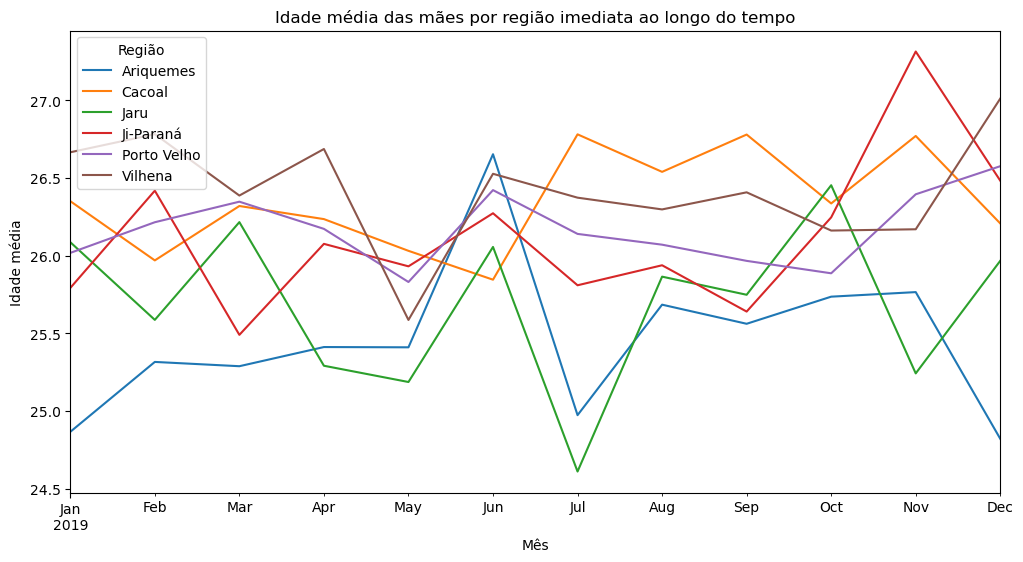

In [38]:
# Dicionário fornecido
imediatas = { "Candeias do Jamari": "Porto Velho",
    "Guajará-Mirim": "Porto Velho",
    "Itapuã do Oeste": "Porto Velho",
    "Nova Mamoré": "Porto Velho",
    "Porto Velho": "Porto Velho",
    "Ariquemes": "Ariquemes",
    "Alto Paraíso": "Ariquemes",
    "Buritis": "Ariquemes",
    "Cacaulândia": "Ariquemes",
    "Campo Novo de Rondônia": "Ariquemes",
    "Cujubim": "Ariquemes",
    "Monte Negro": "Ariquemes",
    "Rio Crespo": "Ariquemes",
    "Jaru": "Jaru",
    "Governador Jorge Teixeira": "Jaru",
    "Machadinho D'Oeste": "Jaru",
    "Theobroma": "Jaru",
    "Vale do Anari": "Jaru",
    "Alvorada D'Oeste": "Ji-Paraná",
    "Costa Marques": "Ji-Paraná",
    "Ji-Paraná": "Ji-Paraná",
    "Mirante da Serra": "Ji-Paraná",
    "Nova União": "Ji-Paraná",
    "Ouro Preto do Oeste": "Ji-Paraná",
    "Presidente Médici": "Ji-Paraná",
    "São Francisco do Guaporé": "Ji-Paraná",
    "São Miguel do Guaporé": "Ji-Paraná",
    "Seringueiras": "Ji-Paraná",
    "Teixeirópolis": "Ji-Paraná",
    "Urupá": "Ji-Paraná",
    "Vale do Paraíso": "Ji-Paraná",
    "Cacoal": "Cacoal",
    "Alta Floresta D'Oeste": "Cacoal",
    "Alto Alegre dos Parecis": "Cacoal",
    "Castanheiras": "Cacoal",
    "Espigão D'Oeste": "Cacoal",
    "Ministro Andreazza": "Cacoal",
    "Nova Brasilândia D'Oeste": "Cacoal",
    "Novo Horizonte do Oeste": "Cacoal",
    "Parecis": "Cacoal",
    "Pimenta Bueno": "Cacoal",
    "Primavera de Rondônia": "Cacoal",
    "Rolim de Moura": "Cacoal",
    "Santa Luzia D'Oeste": "Cacoal",
    "São Felipe D'Oeste": "Cacoal",
    "Vilhena": "Vilhena",
    "Cabixi": "Vilhena",
    "Cerejeiras": "Vilhena",
    "Chupinguaia": "Vilhena",
    "Colorado do Oeste": "Vilhena",
    "Corumbiara": "Vilhena",
    "Pimenteiras do Oeste": "Vilhena" } 

# Criar coluna de região
df['regiao_imediata'] = df['munResNome'].map(imediatas)

# Garantir tipo datetime
df['DTNASC'] = pd.to_datetime(df['DTNASC'])

# Criar coluna de mês
df['mes'] = df['DTNASC'].dt.to_period('M')

# Agrupamento
idade_media = df.groupby(['mes', 'regiao_imediata'])['IDADEMAE'].mean().unstack()

# Plot
idade_media.plot(figsize=(12,6))
plt.title('Idade média das mães por região imediata ao longo do tempo')
plt.xlabel('Mês')
plt.ylabel('Idade média')
plt.legend(title='Região')
plt.show()

### 5. Utilize a tabela do link abaixo e crie faixas utilizando o mapping e gere agrupamentos utilizando essas faixas como chave


### 5.1 IDH
A - https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_IDH-M


In [61]:
idh_map = {
    'Porto Velho': 0.736,
    'Ariquemes': 0.702,
    'Vilhena': 0.731,
    'Cacoal': 0.718,
    'Ji-Paraná': 0.714,
    'Pimenta Bueno': 0.710,
    'Rolim de Moura': 0.700
}

df['IDH'] = df['munResNome'].map(idh_map)

# Criando faixas
df['faixa_idh'] = pd.cut(
    df['IDH'],
    bins=[0, 0.6, 0.7, 0.8],
    labels=['Baixo', 'Médio', 'Alto']
)

#idh_group = df.groupby('faixa_idh')[variaveis].agg(['mean', 'median', 'std'])
idh_group = df.groupby('faixa_idh', observed=True)[variaveis].agg(['mean', 'median', 'std'])

In [63]:
df['faixa_idh'].value_counts()

faixa_idh
Alto     15928
Médio      927
Baixo        0
Name: count, dtype: int64

### 5.2 IFDM
B - https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_IFDM


In [73]:
ifdm_map = {
    'Porto Velho': 0.75,
    'Teixeirópolis': 0.6500,
    'Espigão dOeste': 0.5973,
    'Cacoal': 0.7111
}

df['IFDM'] = df['munResNome'].map(ifdm_map)

df['faixa_ifdm'] = pd.cut(
    df['IFDM'],
    bins=[0, 0.6, 0.8, 1],
    labels=['Baixo', 'Médio', 'Alto']
)

#ifdm_group = df.groupby('faixa_ifdm')[variaveis].agg(['mean', 'median', 'std'])
idh_group = df.groupby('faixa_ifdm', observed=True)[variaveis].agg(['mean', 'median', 'std'])

In [79]:
df['faixa_ifdm'].value_counts()

faixa_ifdm
Médio    9875
Baixo       0
Alto        0
Name: count, dtype: int64

### 5.3 PIB
C - https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_PIB


In [97]:
pib_map = {
    'Porto Velho': 20059522,
    'Ji-Paraná': 4231113,
    'Vilhena': 4215046,
    'Ariquemes': 3209761    
}

#df['PIB'] = df['munResNome'].map(pib_map)

#df['faixa_pib'] = pd.qcut(df['PIB'], q=3, labels=['Baixo', 'Médio', 'Alto'])

#pib_group = df.groupby('faixa_pib')[variaveis].agg(['mean', 'median', 'std'])

df['faixa_pib'] = pd.cut(
    df['PIB'],
    bins=3,
    labels=['Baixo', 'Médio', 'Alto']
)

pib_group = df.groupby('faixa_pib', observed=True)[variaveis].agg(['mean', 'median', 'std'])

In [99]:
df['PIB'].value_counts()

PIB
20059522.0    8437
4231113.0     2182
3209761.0     1729
4215046.0     1590
Name: count, dtype: int64

### Analise as respostas encontradas, tire algum insight delas, conte pra gente algo encontrado nos dados.

Exemplo:
- Ah, descobri que a idade mediana das mulheres que deram a luz no ano de 2019 dos municipios com o PIB mais alto é a maior dentre todas.

## Análise:
A análise por faixas de PIB mostrou uma forte concentração de registros no município de Porto Velho, que se encontra na faixa mais alta de PIB. Isso indica uma possível centralização econômica no estado, refletindo também maior volume de nascimentos registrados nessa região.

OBS:
A limitação de municípios considerados na análise de PIB pode influenciar a generalização dos resultados.